# DBSCAN Clustering Demonstration In Python

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups points based on the density of their neighborhood. It is particularly effective for identifying clusters of varying shapes and sizes, as well as for detecting outliers.

**Key Features of DBSCAN:**

**1. Density-Based Clustering:**

Points are categorized into core points, border points, and noise.

- A core point has at least min_samples points within an eps radius.
- A border point is not a core point but lies within the eps radius of a core point.
- Noise points are those that do not belong to any cluster.

**2. Parameter Tuning:**
- eps: The maximum distance between two points to be considered neighbors.
- min_samples: The minimum number of points required to form a dense region.

**3. Non-Parametric:**
- The number of clusters is not predefined, unlike K-Means.
- Clusters are formed based on the density and connected regions.

**4. Handles Noise:**
- DBSCAN can label points as noise (-1) if they do not belong to any dense cluster.

## **Background**
The dataset contains customer demographic information and multiple billing-related variables, reflecting spending behavior across products and services along with customer tenure. Such data may exhibit non-linear patterns and varying cluster shapes, making density-based clustering suitable for uncovering natural customer segments while identifying outliers.

## **Objective**
- To apply DBSCAN clustering 
- To identify naturally occurring customer segments based on age, billing behavior, and tenure, while detecting noise or anomalous customers.


## Dataset Description

| Column Name          | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| Cust_ID              | Unique identifier assigned to each customer                                 |
| Age                  | Age of the customer (in years)                                               |
| BillAmt_Product      | Total billing amount generated from product purchases                        |
| BillAmt_Service      | Total billing amount generated from services availed by the customer        |
| BillAmt_Pre          | Previous billing amount (historical bill value before the current period)   |
| Vintage              | Customer tenure or length of association with the organization (in years)   |


### Import Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


### Load Data

In [34]:
df = pd.read_csv('Customer Segments.csv')
df

,Cust_ID,Age,BillAmt_Product,BillAmt_Service,BillAmt_Pre,Vintage
0,82078,49,81128,48203,62975,5
1,57215,34,59480,17263,23634,5
2,66970,58,65363,30661,45889,6
3,77319,48,84073,47181,43186,7
4,29564,26,10541,3551,12753,1
...,...,...,...,...,...,...
24019,85110,48,73131,40844,46006,5
24020,49309,32,56764,15153,39221,3
24021,76508,57,96170,41639,58239,7
24022,18883,29,9559,4388,14152,1


In [35]:
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 24024
Number of columns: 6


### Subset data by deleting CustomerID for clustering


In [36]:
df1 = df.drop(columns=['Cust_ID'])
print(df1.head())

   Age  BillAmt_Product  BillAmt_Service  BillAmt_Pre  Vintage
0   49            81128            48203        62975        5
1   34            59480            17263        23634        5
2   58            65363            30661        45889        6
3   48            84073            47181        43186        7
4   26            10541             3551        12753        1


### Standardise all variables using scale function


In [37]:
# Standardize variables
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)
df_scaled[:5]

array([[ 0.75464922,  1.19289574,  1.83512555,  1.65465418,  0.55750441],
       [-0.46042336,  0.46620692, -0.16443829, -0.47878543,  0.55750441],
       [ 1.48369277,  0.66368984,  0.70143618,  0.72809031,  0.9704248 ],
       [ 0.67364438,  1.29175469,  1.76907661,  0.58150819,  1.38334519],
       [-1.10846206, -1.17659724, -1.05060569, -1.06885575, -1.09417716]])

### DBSCAN

### 1. Visualize Elbow Plot : Plot K-th Nearest Neighbor distances to find optimal eps
The "elbow point" in the plot suggests an optimal value for eps. Typically, this is where the slope of the curve changes most abruptly.


Parameter Selection:
1. eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
2. min_samples: The number of samples in a neighborhood for a point to be considered as a core point. For choosing min_sample we use 2 × number of features

In [38]:
min_samples = 10

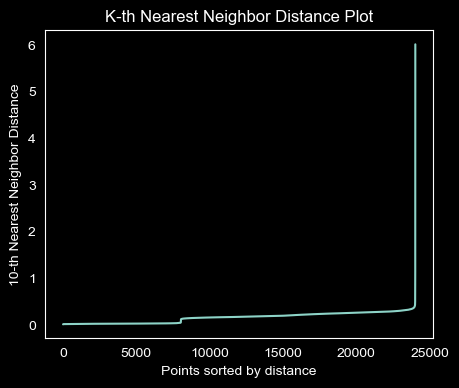

In [39]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

#Plot K-th Nearest Neighbor distances to find optimal eps
k = min_samples
nearest_neighbors = NearestNeighbors(n_neighbors=k)
neighbors = nearest_neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)

sorted_distances = np.sort(distances[:, k - 1])
plt.figure(figsize=(5,4))
plt.plot(sorted_distances)
plt.title("K-th Nearest Neighbor Distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-th Nearest Neighbor Distance")
plt.grid()
plt.show()

### Inference

The k-distance plot exhibits a clear elbow around ε ≈ 0.2, marking the transition from dense regions to sparse points. Hence, ε = 0.2 is selected to ensure meaningful density separation while preventing overly permissive clustering.

### 2. Apply DBSCAN



In [40]:
eps = 0.19 #Adjust this based on the elbow in the plot

ε = 0.19 lies close to the elbow of the k-distance plot and provides a stable balance between cluster separation and noise detection, avoiding both over-splitting and over-merging.

**Note:**
DBSCAN is sensitive to ε because ε defines what we mean by “dense”. Small changes can change connectivity, which can merge or split clusters. Hence, multiple ε values can be valid depending on the analysis goal.

In [41]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters = dbscan.fit_predict(df_scaled)

In [42]:
# Total number of points
n_total = df_scaled.shape[0]

# Core points
n_core_points = len(dbscan.core_sample_indices_)
print("Number of core points:", n_core_points)
print("Percentage of core points:", n_core_points / n_total * 100)

# Noise points (label = -1)
n_noise_points = np.sum(dbscan.labels_ == -1)
print("Number of noise points:", n_noise_points)
print("Percentage of noise points:", n_noise_points / n_total * 100)

# Number of clusters (excluding noise)
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print("Number of clusters:", n_clusters)


Number of core points: 13797
Percentage of core points: 57.430069930069926
Number of noise points: 8008
Percentage of noise points: 33.33333333333333
Number of clusters: 12


### Inference 

- About 57% core points indicate well-defined dense regions in the data.

- Around 33% noise points show DBSCAN’s ability to identify outliers.

- 12 clusters represent meaningful density-based groupings without over-fragmentation.

**Note:** 
DBSCAN discovers clusters based on data density and identifies noise, whereas K-means forces all points into a pre-defined number of clusters.

#### Adding Clusters to original dataframe

In [43]:
df['Cluster'] = clusters
df

,Cust_ID,Age,BillAmt_Product,BillAmt_Service,BillAmt_Pre,Vintage,Cluster
0,82078,49,81128,48203,62975,5,-1
1,57215,34,59480,17263,23634,5,0
2,66970,58,65363,30661,45889,6,-1
3,77319,48,84073,47181,43186,7,-1
4,29564,26,10541,3551,12753,1,1
...,...,...,...,...,...,...,...
24019,85110,48,73131,40844,46006,5,-1
24020,49309,32,56764,15153,39221,3,2
24021,76508,57,96170,41639,58239,7,-1
24022,18883,29,9559,4388,14152,1,1


In [44]:
df['Cluster'].value_counts()

Cluster
 1     8035
-1     8008
 2     2090
 0     1983
 4     1945
 3     1894
 5       18
 10      10
 7       10
 9       10
 8       10
 6       10
 11       1
Name: count, dtype: int64

#### Note : Cluster -1 represents noise which does not belong to any cluster

#### Analyzing Segments/Clusters

In [45]:
seg_analysis = (
    df.groupby('Cluster')
      .agg(
          Count=('Cluster', 'size'),
          Age=('Age', 'mean'),
          BillAmt_Product=('BillAmt_Product', 'mean'),
          BillAmt_Service=('BillAmt_Service', 'mean'),
          BillAmt_Pre=('BillAmt_Pre', 'mean'),
          Vintage=('Vintage', 'mean')
      )
      .reset_index()
      .round(2)
)
seg_analysis

,Cluster,Count,Age,BillAmt_Product,BillAmt_Service,BillAmt_Pre,Vintage
0,-1,8008,54.57,81321.08,39477.75,54592.87,6.42
1,0,1983,37.39,42591.61,16047.36,30203.10,5.00
2,1,8035,26.99,12577.04,3769.15,12508.38,1.00
3,2,2090,37.30,42370.04,16070.19,30139.07,3.00
4,3,1894,37.28,42925.67,16008.23,29961.20,2.00
5,4,1945,37.57,42717.83,16042.19,30388.26,4.00
6,5,18,58.28,87430.94,34368.28,63493.78,8.00
7,6,10,47.80,75327.70,35518.20,51025.60,6.00
8,7,10,57.30,73684.90,36418.60,42266.80,5.00
9,8,10,46.20,84098.20,43501.10,44566.50,8.00


### 3. Visualize the clusters using PCA for dimensionality reduction

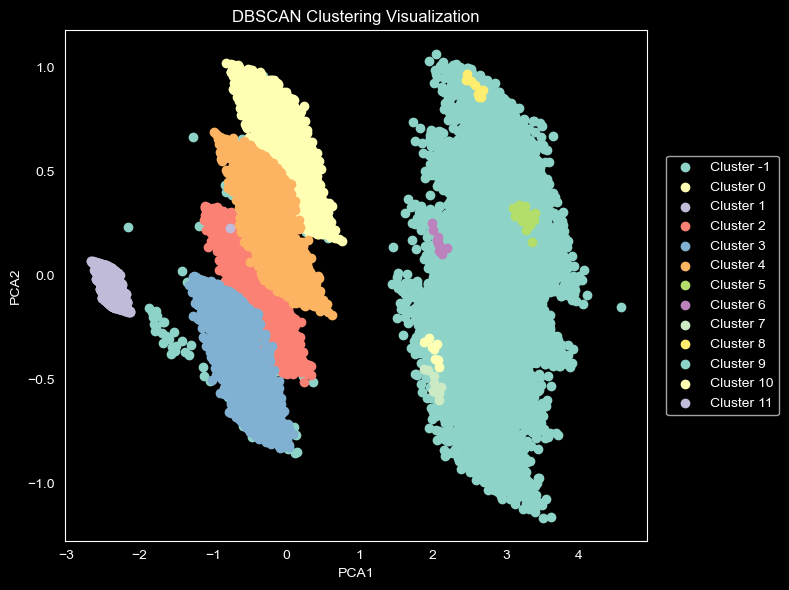

In [46]:
from sklearn.decomposition import PCA

#Visualize the clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled)

# Create a DataFrame for visualization
result_df = pd.DataFrame(reduced_data, columns=["PCA1", "PCA2"])
result_df['Cluster'] = clusters

# Plot the clusters
plt.figure(figsize=(8, 6))
for cluster in np.unique(clusters):
    subset = result_df[result_df['Cluster'] == cluster]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster}')
plt.title("DBSCAN Clustering Visualization")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.grid()
plt.show()

### 4. Evaluation Using Silhouette Score

**Silhouette Score** is an internal clustering evaluation metric that measures **how similar a data point is to its own cluster compared to other clusters**, indicating the quality of cluster separation and cohesion.

Silhouette score ranges from -1 to +1

- Close to +1 → well-separated clusters

- Around 0 → overlapping clusters

- Negative → incorrect clustering

In [47]:
from sklearn.metrics import silhouette_score
# Mask to ignore noise points
mask = clusters != -1

X_no_noise = df_scaled[mask]
labels_no_noise = clusters[mask]
sil_score = silhouette_score(X_no_noise, labels_no_noise)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.4298742504397286


### Inference
A Silhouette Score of ~0.43 indicates moderately well-separated clusters—the clusters formed by DBSCAN have reasonable internal cohesion and separation, but there is still some overlap between clusters.